<a href="https://colab.research.google.com/github/IremOzbek/CBIS-DDSM_dataset/blob/main/CBIS_DDSM_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Gerekli kütüphaneleri kur
!pip install -q kaggle opencv-python-headless Pillow tqdm matplotlib seaborn scikit-learn
print("✅ Kütüphaneler hazır.")

✅ Kütüphaneler hazır.


In [ ]:
import os, shutil, json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print("✅ İmport tamamlandı.")

✅ İmport tamamlandı.


In [ ]:
from google.colab import files

# kaggle.com > Settings > API > "Create New Token" ile kaggle.json indir
print("📂 kaggle.json dosyanızı yükleyin:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_key = list(uploaded.values())[0]
if isinstance(kaggle_key, bytes):
    kaggle_key = kaggle_key.decode()
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_key)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle kimlik doğrulama tamamlandı.")

📂 kaggle.json dosyanızı yükleyin:


Saving kaggle.json to kaggle.json
✅ Kaggle kimlik doğrulama tamamlandı.


In [ ]:
# ─── Veri Setini İndir ────────────────────────────────────────────────────────
# NOT: ~10 GB — 10-20 dakika sürebilir (Colab ağ hızına bağlı)

DATASET_SLUG = 'awsaf49/cbis-ddsm-breast-cancer-image-dataset'
DOWNLOAD_DIR = '/content/cbis_raw'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("⬇️  İndiriliyor... (bu işlem 10-20 dakika sürebilir)")
!kaggle datasets download -d {DATASET_SLUG} -p {DOWNLOAD_DIR} --unzip
print("\n✅ İndirme tamamlandı!")

⬇️  İndiriliyor... (bu işlem 10-20 dakika sürebilir)
Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:31<00:00, 167MB/s]


✅ İndirme tamamlandı!


In [ ]:
import os
import pandas as pd

CSV_DIR = "/content/cbis_raw/csv"
JPEG_DIR = "/content/cbis_raw/jpeg"

mass_train = pd.read_csv(os.path.join(CSV_DIR,"mass_case_description_train_set.csv"))
mass_test  = pd.read_csv(os.path.join(CSV_DIR,"mass_case_description_test_set.csv"))
calc_train = pd.read_csv(os.path.join(CSV_DIR,"calc_case_description_train_set.csv"))
calc_test  = pd.read_csv(os.path.join(CSV_DIR,"calc_case_description_test_set.csv"))

df = pd.concat([mass_train, mass_test, calc_train, calc_test], ignore_index=True)

print("GENEL SHAPE:", df.shape)
print("\nCOLUMNS:")
print(df.columns)

GENEL SHAPE: (3568, 17)

COLUMNS:
Index(['patient_id', 'breast_density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'mass shape', 'mass margins',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path', 'breast density',
       'calc type', 'calc distribution'],
      dtype='object')


In [ ]:
print("\nPATHOLOGY DAĞILIMI:")
print(df["pathology"].value_counts())


PATHOLOGY DAĞILIMI:
pathology
MALIGNANT                  1457
BENIGN                     1429
BENIGN_WITHOUT_CALLBACK     682
Name: count, dtype: int64


In [ ]:
print("\nIMAGE VIEW DAĞILIMI:")
print(df["image view"].value_counts())


IMAGE VIEW DAĞILIMI:
image view
MLO    1896
CC     1672
Name: count, dtype: int64


In [ ]:
print("\nUNIQUE PATIENT COUNT:", df["patient_id"].nunique())
print("\nÖRNEK PATIENT ID'ler:")
print(df["patient_id"].head(10))


UNIQUE PATIENT COUNT: 1566

ÖRNEK PATIENT ID'ler:
0    P_00001
1    P_00001
2    P_00004
3    P_00004
4    P_00004
5    P_00009
6    P_00009
7    P_00015
8    P_00018
9    P_00018
Name: patient_id, dtype: object


In [ ]:
dicom_df = pd.read_csv(os.path.join(CSV_DIR,"dicom_info.csv"))

print("\nSERIES DESCRIPTION:")
print(dicom_df["SeriesDescription"].value_counts())


SERIES DESCRIPTION:
SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64


In [ ]:
full = dicom_df[dicom_df["SeriesDescription"]=="full mammogram images"]

print("\nFULL MAMMOGRAM SAYISI:", len(full))
print(full["image_path"].head())


FULL MAMMOGRAM SAYISI: 2857
1     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
11    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.210396...
12    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.749566...
15    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.987658...
Name: image_path, dtype: object


In [ ]:
print("\nCROPPED / ROI / FULL KARŞILAŞTIRMA:")
print(dicom_df["SeriesDescription"].value_counts())


CROPPED / ROI / FULL KARŞILAŞTIRMA:
SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64


In [ ]:
sample_path = full["image_path"].iloc[0]
real_path = os.path.join(JPEG_DIR, sample_path.replace("CBIS-DDSM/",""))

print("SAMPLE PATH:", real_path)
print("EXISTS:", os.path.exists(real_path))

SAMPLE PATH: /content/cbis_raw/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
EXISTS: False


In [ ]:
import os

dicom_df = pd.read_csv(os.path.join(CSV_DIR,"dicom_info.csv"))

full = dicom_df[dicom_df["SeriesDescription"]=="full mammogram images"].copy()

def fix_path(x):
    x = x.replace("CBIS-DDSM/jpeg/", "")
    x = x.replace("CBIS-DDSM/", "")
    return os.path.join(JPEG_DIR, x)

full["full_path"] = full["image_path"].apply(fix_path)

full["exists"] = full["full_path"].apply(os.path.exists)

print("EXISTS TRUE:", full["exists"].sum())
print("TOTAL:", len(full))

EXISTS TRUE: 2857
TOTAL: 2857


In [32]:
import os
import pandas as pd

CSV_DIR = "/content/cbis_raw/csv"

# CSV dosyalarını yükle
mass_train = pd.read_csv(os.path.join(CSV_DIR, "mass_case_description_train_set.csv"))
mass_test  = pd.read_csv(os.path.join(CSV_DIR, "mass_case_description_test_set.csv"))

calc_train = pd.read_csv(os.path.join(CSV_DIR, "calc_case_description_train_set.csv"))
calc_test  = pd.read_csv(os.path.join(CSV_DIR, "calc_case_description_test_set.csv"))

dicom_df = pd.read_csv(os.path.join(CSV_DIR, "dicom_info.csv"))

# =========================================================
# 1. SHAPE
# =========================================================

print("MASS TRAIN:", mass_train.shape)
print("MASS TEST :", mass_test.shape)

print("CALC TRAIN:", calc_train.shape)
print("CALC TEST :", calc_test.shape)

print("DICOM INFO:", dicom_df.shape)

# =========================================================
# 2. SÜTUNLAR
# =========================================================

print("\n=== MASS TRAIN COLUMNS ===")
print(mass_train.columns.tolist())

print("\n=== CALC TRAIN COLUMNS ===")
print(calc_train.columns.tolist())

print("\n=== DICOM INFO COLUMNS ===")
print(dicom_df.columns.tolist())

# =========================================================
# 3. PATHOLOGY DAĞILIMI
# =========================================================

print("\n=== MASS PATHOLOGY ===")
print(mass_train["pathology"].value_counts())

print("\n=== CALC PATHOLOGY ===")
print(calc_train["pathology"].value_counts())

# =========================================================
# 4. IMAGE VIEW (CC / MLO)
# =========================================================

print("\n=== MASS IMAGE VIEW ===")
print(mass_train["image view"].value_counts())

print("\n=== CALC IMAGE VIEW ===")
print(calc_train["image view"].value_counts())

# =========================================================
# 5. IMAGE FILE PATH ÖRNEKLERİ
# =========================================================

print("\n=== MASS IMAGE FILE PATH SAMPLE ===")
print(mass_train["image file path"].head(5))

print("\n=== DICOM IMAGE PATH SAMPLE ===")
print(dicom_df["image_path"].dropna().head(5))

# =========================================================
# 6. SERIES DESCRIPTION
# =========================================================

print("\n=== SERIES DESCRIPTION ===")
print(dicom_df["SeriesDescription"].value_counts())

# =========================================================
# 7. PATIENT ID KONTROL
# =========================================================

print("\n=== UNIQUE PATIENT COUNT ===")
print(mass_train["patient_id"].nunique())

print("\n=== SAMPLE PATIENT IDs ===")
print(mass_train["patient_id"].head(10))

MASS TRAIN: (1318, 14)
MASS TEST : (378, 14)
CALC TRAIN: (1546, 14)
CALC TEST : (326, 14)
DICOM INFO: (10237, 38)

=== MASS TRAIN COLUMNS ===
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']

=== CALC TRAIN COLUMNS ===
['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']

=== DICOM INFO COLUMNS ===
['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation'

In [33]:
import os
from pathlib import Path

# =========================================================
# FULL MAMMOGRAM FİLTRESİ
# =========================================================

full_df = dicom_df[
    dicom_df["SeriesDescription"] == "full mammogram images"
].copy()

print("FULL MAMMOGRAM SHAPE:", full_df.shape)

# =========================================================
# PATH DÜZELTME
# =========================================================

JPEG_DIR = "/content/cbis_raw/jpeg"

def fix_full_path(x):
    x = x.replace("CBIS-DDSM/jpeg/", "")
    x = x.replace("CBIS-DDSM/", "")
    return os.path.join(JPEG_DIR, x)

full_df["full_path"] = full_df["image_path"].apply(fix_full_path)

# =========================================================
# DOSYA GERÇEKTEN VAR MI?
# =========================================================

full_df["exists"] = full_df["full_path"].apply(os.path.exists)

print("\nPATH EXISTS:")
print(full_df["exists"].value_counts())

# =========================================================
# ÖRNEK PATH
# =========================================================

sample_row = full_df.iloc[0]

print("\nORIGINAL PATH:")
print(sample_row["image_path"])

print("\nFIXED PATH:")
print(sample_row["full_path"])

print("\nFILE EXISTS:")
print(sample_row["exists"])

# =========================================================
# SADECE GERÇEK DOSYALAR
# =========================================================

full_df = full_df[full_df["exists"] == True]

print("\nFINAL FULL DF:")
print(full_df.shape)

FULL MAMMOGRAM SHAPE: (2857, 38)

PATH EXISTS:
exists
True    2857
Name: count, dtype: int64

ORIGINAL PATH:
CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg

FIXED PATH:
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg

FILE EXISTS:
True

FINAL FULL DF:
(2857, 40)


In [34]:
import pandas as pd

# =========================================================
# TÜM CASE CSV'LERİNİ BİRLEŞTİR
# =========================================================

all_cases = pd.concat([
    mass_train,
    mass_test,
    calc_train,
    calc_test
], ignore_index=True)

print("ALL CASES:", all_cases.shape)

# =========================================================
# GEREKLİ SÜTUNLAR
# =========================================================

all_cases = all_cases[[
    "patient_id",
    "image view",
    "left or right breast",
    "pathology",
    "image file path"
]].copy()

print("\nCOLUMNS:")
print(all_cases.columns)

# =========================================================
# LABEL OLUŞTUR
# =========================================================

def make_label(x):
    if x == "MALIGNANT":
        return "malignant"
    elif x in ["BENIGN", "BENIGN_WITHOUT_CALLBACK"]:
        return "benign"
    return None

all_cases["label"] = all_cases["pathology"].apply(make_label)

# =========================================================
# LABEL DAĞILIMI
# =========================================================

print("\nLABEL DISTRIBUTION:")
print(all_cases["label"].value_counts())

# =========================================================
# CC / MLO DAĞILIMI
# =========================================================

print("\nIMAGE VIEW:")
print(all_cases["image view"].value_counts())

# =========================================================
# ÖRNEK IMAGE FILE PATH
# =========================================================

print("\nSAMPLE IMAGE FILE PATH:")
print(all_cases["image file path"].head(10))

# =========================================================
# PATIENT SAYISI
# =========================================================

print("\nUNIQUE PATIENT COUNT:")
print(all_cases["patient_id"].nunique())

ALL CASES: (3568, 17)

COLUMNS:
Index(['patient_id', 'image view', 'left or right breast', 'pathology',
       'image file path'],
      dtype='object')

LABEL DISTRIBUTION:
label
benign       2111
malignant    1457
Name: count, dtype: int64

IMAGE VIEW:
image view
MLO    1896
CC     1672
Name: count, dtype: int64

SAMPLE IMAGE FILE PATH:
0    Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...
1    Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...
2    Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...
3    Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...
4    Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...
5    Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.959...
6    Mass-Training_P_00009_RIGHT_MLO/1.3.6.1.4.1.95...
7    Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...
8    Mass-Training_P_00018_RIGHT_CC/1.3.6.1.4.1.959...
9    Mass-Training_P_00018_RIGHT_MLO/1.3.6.1.4.1.95...
Name: image file path, dtype: object

UNIQUE PATIENT COUNT:
1566


In [35]:
import re

# =========================================================
# CASE KEY
# =========================================================

all_cases["case_key"] = all_cases["image file path"].apply(
    lambda x: x.split("/")[0]
)

print("CASE KEY SAMPLE:")
print(all_cases["case_key"].head())

# =========================================================
# FULL PATH SAMPLE
# =========================================================

print("\nFULL IMAGE PATH SAMPLE:")
print(full_df["image_path"].head(10))

# =========================================================
# FULL IMAGE KEY ÇIKAR
# =========================================================

def extract_key(x):
    x = x.upper()

    patterns = [
        r'MASS-TRAINING_P_\d+_(LEFT|RIGHT)_(CC|MLO)',
        r'MASS-TEST_P_\d+_(LEFT|RIGHT)_(CC|MLO)',
        r'CALC-TRAINING_P_\d+_(LEFT|RIGHT)_(CC|MLO)',
        r'CALC-TEST_P_\d+_(LEFT|RIGHT)_(CC|MLO)'
    ]

    for p in patterns:
        m = re.search(p, x)
        if m:
            return m.group(0)

    return None

full_df["case_key"] = full_df["image_path"].apply(extract_key)

# =========================================================
# NULL KEY SAYISI
# =========================================================

print("\nNULL CASE KEY COUNT:")
print(full_df["case_key"].isna().sum())

# =========================================================
# ÖRNEK KEYLER
# =========================================================

print("\nFULL DF CASE KEY SAMPLE:")
print(full_df["case_key"].dropna().head(10))

CASE KEY SAMPLE:
0      Mass-Training_P_00001_LEFT_CC
1     Mass-Training_P_00001_LEFT_MLO
2      Mass-Training_P_00004_LEFT_CC
3     Mass-Training_P_00004_LEFT_MLO
4    Mass-Training_P_00004_RIGHT_MLO
Name: case_key, dtype: object

FULL IMAGE PATH SAMPLE:
1     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
11    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.210396...
12    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.749566...
15    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.987658...
16    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.362722...
17    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.106891...
18    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.121186...
23    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.295360...
24    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.146562...
Name: image_path, dtype: object

NULL CASE KEY COUNT:
2857

FULL DF CASE KEY SAMPLE:
Series([], Name: case_key, dtype: object)


In [36]:
from pathlib import Path
import os

JPEG_DIR = "/content/cbis_raw/jpeg"

# =========================================================
# TÜM JPG DOSYALARINI TARA
# =========================================================

all_jpgs = list(Path(JPEG_DIR).rglob("*.jpg"))

print("TOTAL JPG COUNT:", len(all_jpgs))

# =========================================================
# İLK 10 DOSYA
# =========================================================

print("\nSAMPLE JPG FILES:")
for p in all_jpgs[:10]:
    print(p)

# =========================================================
# CSV PATH İÇİN ÖRNEK
# =========================================================

sample_csv_path = all_cases["image file path"].iloc[0]

print("\nCSV IMAGE FILE PATH:")
print(sample_csv_path)

# =========================================================
# CSV SONUNDAKİ DOSYA ADI
# =========================================================

target_name = sample_csv_path.split("/")[-1]

print("\nTARGET FILE NAME:")
print(target_name)

# =========================================================
# JPG DOSYALARINDA ARA
# =========================================================

matches = [str(p) for p in all_jpgs if target_name in str(p)]

print("\nMATCH COUNT:", len(matches))

print("\nMATCH SAMPLE:")
for m in matches[:5]:
    print(m)

TOTAL JPG COUNT: 10237

SAMPLE JPG FILES:
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.11223356112180875716745240381398643422/1-122.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.11223356112180875716745240381398643422/2-274.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.364350115212430791205570300382328406712/1-141.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.364350115212430791205570300382328406712/2-293.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.74027474310821018314806355672297628810/1-134.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.215811327512259684015646982651405467155/1-092.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.51457123011337046939870076193775211718/2-254.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.51457123011337046939870076193775211718/1-146.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.126931471711950064228802134232479763588/1-259.jpg
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.376080985712438416829430109780759

In [37]:
# =========================================================
# FULL MAMMOGRAM DICOM META ANALİZİ
# =========================================================

cols_to_check = [
    "PatientID",
    "Laterality",
    "SeriesDescription",
    "StudyID",
    "image_path"
]

available_cols = [c for c in cols_to_check if c in full_df.columns]

print("AVAILABLE COLUMNS:")
print(available_cols)

# =========================================================
# İLK SATIRLAR
# =========================================================

print("\nFULL DF SAMPLE:")
print(full_df[available_cols].head(20))

# =========================================================
# LATERALITY
# =========================================================

if "Laterality" in full_df.columns:
    print("\nLATERALITY:")
    print(full_df["Laterality"].value_counts(dropna=False))

# =========================================================
# PATIENT ID
# =========================================================

if "PatientID" in full_df.columns:
    print("\nPATIENT ID SAMPLE:")
    print(full_df["PatientID"].head(20))

    print("\nUNIQUE PATIENT ID COUNT:")
    print(full_df["PatientID"].nunique())

# =========================================================
# STUDY ID
# =========================================================

if "StudyID" in full_df.columns:
    print("\nSTUDY ID SAMPLE:")
    print(full_df["StudyID"].head(20))

# =========================================================
# IMAGE PATH
# =========================================================

print("\nIMAGE PATH SAMPLE:")
print(full_df["image_path"].head(20))

AVAILABLE COLUMNS:
['PatientID', 'Laterality', 'SeriesDescription', 'StudyID', 'image_path']

FULL DF SAMPLE:
                          PatientID Laterality      SeriesDescription StudyID  \
1    Mass-Training_P_01754_RIGHT_CC          R  full mammogram images    DDSM   
2    Calc-Training_P_00232_RIGHT_CC          R  full mammogram images    DDSM   
11  Mass-Training_P_01206_RIGHT_MLO          R  full mammogram images    DDSM   
12  Calc-Training_P_00506_RIGHT_MLO          R  full mammogram images    DDSM   
15   Calc-Training_P_01823_RIGHT_CC          R  full mammogram images    DDSM   
16  Mass-Training_P_00122_RIGHT_MLO          R  full mammogram images    DDSM   
17  Mass-Training_P_01175_RIGHT_MLO          R  full mammogram images    DDSM   
18   Mass-Training_P_00411_RIGHT_CC          R  full mammogram images    DDSM   
23   Mass-Training_P_00004_LEFT_MLO          L  full mammogram images    DDSM   
24   Mass-Training_P_01946_RIGHT_CC          R  full mammogram images    DDSM   

In [39]:
import os
import pandas as pd

# =========================================================
# FULL MAMMOGRAM PATH DÜZELT
# =========================================================

full_df["fixed_path"] = full_df["image_path"].apply(
    lambda x: x.replace(
        "CBIS-DDSM/jpeg",
        "/content/cbis_raw/jpeg"
    )
)

# =========================================================
# DOSYA VAR MI?
# =========================================================

full_df["exists"] = full_df["fixed_path"].apply(os.path.exists)

print("PATH EXISTS:")
print(full_df["exists"].value_counts())

# =========================================================
# SADECE VAR OLANLARI AL
# =========================================================

full_df = full_df[full_df["exists"] == True].copy()

print("\nFULL DF SHAPE:")
print(full_df.shape)

# =========================================================
# CASE KEY
# =========================================================

all_cases["case_key"] = all_cases["image file path"].apply(
    lambda x: x.split("/")[0]
)

full_df["case_key"] = full_df["PatientID"]

# =========================================================
# MERGE
# =========================================================

merged = pd.merge(
    all_cases,
    full_df[["case_key", "fixed_path"]],
    on="case_key",
    how="inner"
)

print("\nMERGED SHAPE:")
print(merged.shape)

# =========================================================
# LABEL DAĞILIMI
# =========================================================

print("\nLABEL DISTRIBUTION:")
print(merged["label"].value_counts())

# =========================================================
# IMAGE VIEW
# =========================================================

print("\nIMAGE VIEW:")
print(merged["image view"].value_counts())

# =========================================================
# ÖRNEK PATH
# =========================================================

print("\nSAMPLE IMAGE:")
print(merged["fixed_path"].iloc[0])

print("\nFILE EXISTS:")
print(os.path.exists(merged["fixed_path"].iloc[0]))

# =========================================================
# UNIQUE PATIENT
# =========================================================

print("\nUNIQUE PATIENT:")
print(merged["patient_id"].nunique())

PATH EXISTS:
exists
True    2857
Name: count, dtype: int64

FULL DF SHAPE:
(2857, 42)

MERGED SHAPE:
(3286, 8)

LABEL DISTRIBUTION:
label
benign       1931
malignant    1355
Name: count, dtype: int64

IMAGE VIEW:
image view
MLO    1743
CC     1543
Name: count, dtype: int64

SAMPLE IMAGE:
/content/cbis_raw/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg

FILE EXISTS:
True

UNIQUE PATIENT:
1460


In [40]:
import shutil
from sklearn.model_selection import GroupShuffleSplit

# =========================================================
# DATASET ROOT
# =========================================================

OUTPUT_DIR = "/content/final_dataset"

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

splitter = GroupShuffleSplit(
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        merged,
        groups=merged["patient_id"]
    )
)

train_df = merged.iloc[train_idx].reset_index(drop=True)
test_df  = merged.iloc[test_idx].reset_index(drop=True)

print("TRAIN:", train_df.shape)
print("TEST :", test_df.shape)

# =========================================================
# LABEL DAĞILIMI
# =========================================================

print("\nTRAIN LABEL:")
print(train_df["label"].value_counts())

print("\nTEST LABEL:")
print(test_df["label"].value_counts())

# =========================================================
# KLASÖRLERİ OLUŞTUR
# =========================================================

for split in ["train", "test"]:
    for label in ["benign", "malignant"]:

        os.makedirs(
            os.path.join(
                OUTPUT_DIR,
                split,
                label
            ),
            exist_ok=True
        )

# =========================================================
# COPY FUNCTION
# =========================================================

def copy_images(df, split_name):

    for idx, row in df.iterrows():

        src = row["fixed_path"]

        label = row["label"]

        view = row["image view"]

        patient = row["patient_id"]

        filename = f"{patient}_{view}_{idx}.jpg"

        dst = os.path.join(
            OUTPUT_DIR,
            split_name,
            label,
            filename
        )

        shutil.copy(src, dst)

# =========================================================
# COPY IMAGES
# =========================================================

print("\nCOPY TRAIN...")
copy_images(train_df, "train")

print("COPY TEST...")
copy_images(test_df, "test")

print("\nDATASET CREATED.")

# =========================================================
# FINAL SAYILAR
# =========================================================

for split in ["train", "test"]:
    for label in ["benign", "malignant"]:

        folder = os.path.join(
            OUTPUT_DIR,
            split,
            label
        )

        count = len(os.listdir(folder))

        print(f"{split}/{label}: {count}")

TRAIN: (2594, 8)
TEST : (692, 8)

TRAIN LABEL:
label
benign       1501
malignant    1093
Name: count, dtype: int64

TEST LABEL:
label
benign       430
malignant    262
Name: count, dtype: int64

COPY TRAIN...
COPY TEST...

DATASET CREATED.
train/benign: 1501
train/malignant: 1093
test/benign: 430
test/malignant: 262


In [42]:
import shutil
import os

FINAL_DIR = "/content/final_dataset"   # senin oluşturduğun ana klasör
ZIP_NAME = "/content/final_dataset_zip"

# ZIP oluştur
shutil.make_archive(ZIP_NAME, 'zip', FINAL_DIR)

print("✅ ZIP oluşturuldu:")
print(ZIP_NAME + ".zip")

✅ ZIP oluşturuldu:
/content/final_dataset_zip.zip


In [43]:
from sklearn.utils import resample

def balance_view(df):

    cc_df = df[df["image view"] == "CC"]
    mlo_df = df[df["image view"] == "MLO"]

    min_len = min(len(cc_df), len(mlo_df))

    cc_bal = resample(cc_df, replace=False, n_samples=min_len, random_state=42)
    mlo_bal = resample(mlo_df, replace=False, n_samples=min_len, random_state=42)

    balanced = pd.concat([cc_bal, mlo_bal]).sample(frac=1, random_state=42)

    return balanced


# =========================================================
# BALANCED TRAIN / TEST
# =========================================================

train_balanced = balance_view(train_df)
test_balanced  = balance_view(test_df)

print("TRAIN BALANCED:")
print(train_balanced["image view"].value_counts())

print("\nTEST BALANCED:")
print(test_balanced["image view"].value_counts())

print("\nTRAIN LABEL:")
print(train_balanced["label"].value_counts())

print("\nTEST LABEL:")
print(test_balanced["label"].value_counts())

TRAIN BALANCED:
image view
MLO    1223
CC     1223
Name: count, dtype: int64

TEST BALANCED:
image view
MLO    320
CC     320
Name: count, dtype: int64

TRAIN LABEL:
label
benign       1410
malignant    1036
Name: count, dtype: int64

TEST LABEL:
label
benign       401
malignant    239
Name: count, dtype: int64


In [44]:
import shutil

BAL_DIR = "/content/cbis_ddsm_balanced"

for split in ["train", "test"]:
    for label in ["benign", "malignant"]:
        os.makedirs(os.path.join(BAL_DIR, split, label), exist_ok=True)


def copy_balanced(df, split_name):

    for i, row in df.iterrows():

        src = row["fixed_path"]
        label = row["label"]

        filename = f"{row['patient_id']}_{row['image view']}_{i}.jpg"

        dst = os.path.join(
            BAL_DIR,
            split_name,
            label,
            filename
        )

        shutil.copy(src, dst)


print("COPY TRAIN BALANCED...")
copy_balanced(train_balanced, "train")

print("COPY TEST BALANCED...")
copy_balanced(test_balanced, "test")

print("DONE")

COPY TRAIN BALANCED...
COPY TEST BALANCED...
DONE


In [45]:
print("=== TRAIN LABEL DISTRIBUTION ===")
print(train_df["label"].value_counts())
print(train_df["label"].value_counts(normalize=True) * 100)

print("\n=== TEST LABEL DISTRIBUTION ===")
print(test_df["label"].value_counts())
print(test_df["label"].value_counts(normalize=True) * 100)

print("\n==============================")

print("=== TRAIN IMAGE VIEW DISTRIBUTION ===")
print(train_df["image view"].value_counts())
print(train_df["image view"].value_counts(normalize=True) * 100)

print("\n=== TEST IMAGE VIEW DISTRIBUTION ===")
print(test_df["image view"].value_counts())
print(test_df["image view"].value_counts(normalize=True) * 100)

=== TRAIN LABEL DISTRIBUTION ===
label
benign       1501
malignant    1093
Name: count, dtype: int64
label
benign       57.864302
malignant    42.135698
Name: proportion, dtype: float64

=== TEST LABEL DISTRIBUTION ===
label
benign       430
malignant    262
Name: count, dtype: int64
label
benign       62.138728
malignant    37.861272
Name: proportion, dtype: float64

=== TRAIN IMAGE VIEW DISTRIBUTION ===
image view
MLO    1371
CC     1223
Name: count, dtype: int64
image view
MLO    52.852737
CC     47.147263
Name: proportion, dtype: float64

=== TEST IMAGE VIEW DISTRIBUTION ===
image view
MLO    372
CC     320
Name: count, dtype: int64
image view
MLO    53.757225
CC     46.242775
Name: proportion, dtype: float64


In [46]:
print("\n=== TRAIN: LABEL vs VIEW ===")
print(pd.crosstab(train_df["label"], train_df["image view"]))

print("\n=== TEST: LABEL vs VIEW ===")
print(pd.crosstab(test_df["label"], test_df["image view"]))


=== TRAIN: LABEL vs VIEW ===
image view   CC  MLO
label               
benign      711  790
malignant   512  581

=== TEST: LABEL vs VIEW ===
image view   CC  MLO
label               
benign      199  231
malignant   121  141


In [47]:
print("\n================ BALANCED DATASET ================")

print("\n=== TRAIN BALANCED LABEL ===")
print(train_balanced["label"].value_counts())
print(train_balanced["label"].value_counts(normalize=True) * 100)

print("\n=== TEST BALANCED LABEL ===")
print(test_balanced["label"].value_counts())
print(test_balanced["label"].value_counts(normalize=True) * 100)

print("\n=== TRAIN BALANCED VIEW ===")
print(train_balanced["image view"].value_counts())
print(train_balanced["image view"].value_counts(normalize=True) * 100)

print("\n=== TEST BALANCED VIEW ===")
print(test_balanced["image view"].value_counts())
print(test_balanced["image view"].value_counts(normalize=True) * 100)


================ BALANCED DATASET ================

=== TRAIN BALANCED LABEL ===
label
benign       1410
malignant    1036
Name: count, dtype: int64
label
benign       57.645135
malignant    42.354865
Name: proportion, dtype: float64

=== TEST BALANCED LABEL ===
label
benign       401
malignant    239
Name: count, dtype: int64
label
benign       62.65625
malignant    37.34375
Name: proportion, dtype: float64

=== TRAIN BALANCED VIEW ===
image view
MLO    1223
CC     1223
Name: count, dtype: int64
image view
MLO    50.0
CC     50.0
Name: proportion, dtype: float64

=== TEST BALANCED VIEW ===
image view
MLO    320
CC     320
Name: count, dtype: int64
image view
MLO    50.0
CC     50.0
Name: proportion, dtype: float64


In [48]:
print("\n=== TRAIN BALANCED: LABEL vs VIEW ===")
print(pd.crosstab(train_balanced["label"], train_balanced["image view"]))

print("\n=== TEST BALANCED: LABEL vs VIEW ===")
print(pd.crosstab(test_balanced["label"], test_balanced["image view"]))


=== TRAIN BALANCED: LABEL vs VIEW ===
image view   CC  MLO
label               
benign      711  699
malignant   512  524

=== TEST BALANCED: LABEL vs VIEW ===
image view   CC  MLO
label               
benign      199  202
malignant   121  118


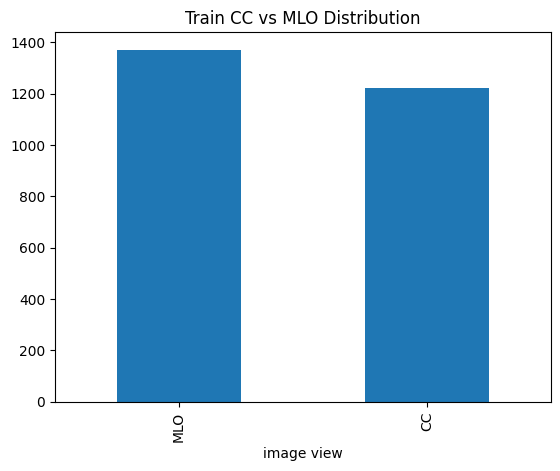

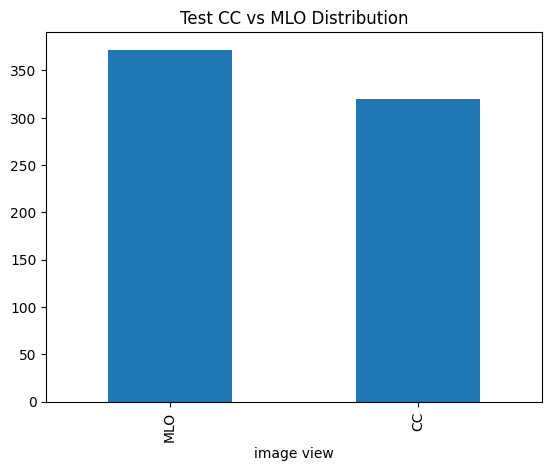

In [49]:
import matplotlib.pyplot as plt

train_df["image view"].value_counts().plot(kind="bar")
plt.title("Train CC vs MLO Distribution")
plt.show()

test_df["image view"].value_counts().plot(kind="bar")
plt.title("Test CC vs MLO Distribution")
plt.show()